## 06-Machine Learning Model

In [1]:
import os
from pyspark.sql import SparkSession


In [2]:
spark = (
    SparkSession.builder
    .appName("Bus_Service_Risk_ML")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")




In [3]:
project_path = r"D:\BigDataCoursework"

processed_path = os.path.join(project_path, "Data", "processed")

train_path = os.path.join(processed_path, "ml_data", "train")
test_path = os.path.join(processed_path, "ml_data", "test")

train_data = spark.read.parquet(train_path)
test_data = spark.read.parquet(test_path)

train_data.show(5, truncate=False)
train_data.printSchema()

+----------------+---------------+--------------+---------+----------------+--------------+----------------+-----------------+------------+-------------------------------+
|Route_Complexity|Number_of_Stops|Departure_Hour|Peak_Hour|Disruption_Count|Has_Disruption|Position_Reports|Has_Live_Tracking|Service_Risk|features                       |
+----------------+---------------+--------------+---------+----------------+--------------+----------------+-----------------+------------+-------------------------------+
|2               |1              |9             |1        |0               |0             |0               |0                |0           |(8,[0,1,2,3],[2.0,1.0,9.0,1.0])|
|2               |1              |11            |0        |0               |0             |0               |0                |0           |(8,[0,1,2],[2.0,1.0,11.0])     |
|2               |1              |12            |0        |0               |0             |0               |0                |0           |(

In [4]:
results_path = os.path.join(project_path, "Results", "charts")
os.makedirs(results_path, exist_ok=True)

## Model 1: Decision Tree Classifier

In [5]:
from pyspark.ml.classification import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    labelCol="Service_Risk",
    featuresCol="features",
    maxDepth=3,
    minInstancesPerNode=3000,
    minInfoGain=0.05,
    seed=42
)
dt_model = dt.fit(train_data)

dt_predictions = dt_model.transform(test_data)

In [6]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

metrics = [
    "accuracy",
    "weightedPrecision",
    "weightedRecall",
    "f1"
]

print("Decision Tree Performance")

for metric in metrics:

    evaluator = MulticlassClassificationEvaluator(
        labelCol="Service_Risk",
        predictionCol="prediction",
        metricName=metric
    )

    score = evaluator.evaluate(dt_predictions)

    print(metric, ":", score)

Decision Tree Performance
accuracy : 0.8949354165741933
weightedPrecision : 0.8949563518434853
weightedRecall : 0.8949354165741932
f1 : 0.8928912083530129


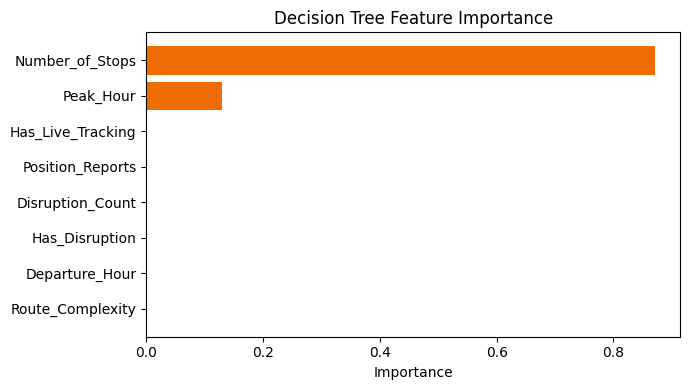

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = [
    "Route_Complexity", "Number_of_Stops", "Departure_Hour", "Peak_Hour",
    "Disruption_Count", "Has_Disruption", "Position_Reports", "Has_Live_Tracking",
]
dt_fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model.featureImportances.toArray()
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(7,4))
plt.barh(dt_fi_df["Feature"], dt_fi_df["Importance"], color="#EF6C00")
plt.xlabel("Importance")
plt.title("Decision Tree Feature Importance")
plt.tight_layout()
plt.savefig(
    os.path.join(results_path, "confusion_matrix_dt.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

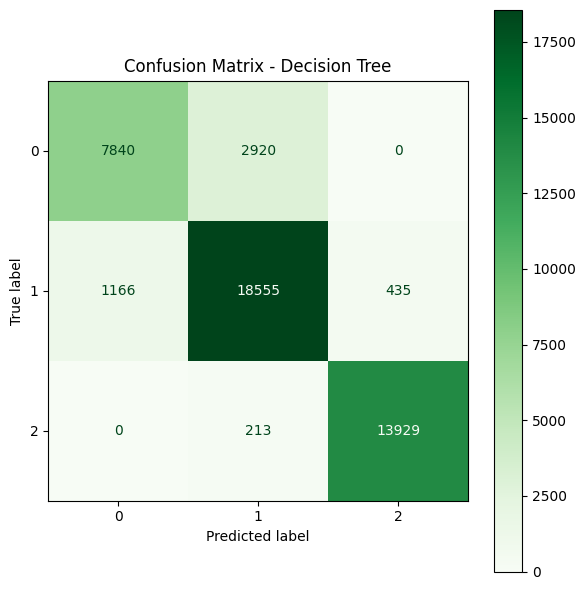

In [8]:
from pyspark.sql.functions import col
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

dt_cm_df = dt_predictions.select(
    col("Service_Risk").cast("int"),
    col("prediction").cast("int")
).toPandas()

cm = confusion_matrix(
    dt_cm_df["Service_Risk"],
    dt_cm_df["prediction"]
)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens", ax=ax)

plt.title("Confusion Matrix - Decision Tree")

plt.tight_layout()

plt.savefig(
    os.path.join(results_path, "confusion_matrix_dt.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model 2: Random Forest Classifier

In [9]:
from pyspark.ml.classification import RandomForestClassifier

rf = RandomForestClassifier(
    labelCol="Service_Risk",
    featuresCol="features",
    numTrees=10,             # much fewer trees
    maxDepth=3,              # shallow trees
    minInstancesPerNode=300,
    featureSubsetStrategy="sqrt",
    seed=42
)

rf_model = rf.fit(train_data)


In [10]:
rf_predictions = rf_model.transform(test_data)
print("Random Forest Performance")

for metric in metrics:

    evaluator = MulticlassClassificationEvaluator(
        labelCol="Service_Risk",
        predictionCol="prediction",
        metricName=metric
    )

    print(metric, ":", evaluator.evaluate(rf_predictions))

Random Forest Performance
accuracy : 0.8931821208220516
weightedPrecision : 0.9031798548460168
weightedRecall : 0.8931821208220516
f1 : 0.8880924987438551


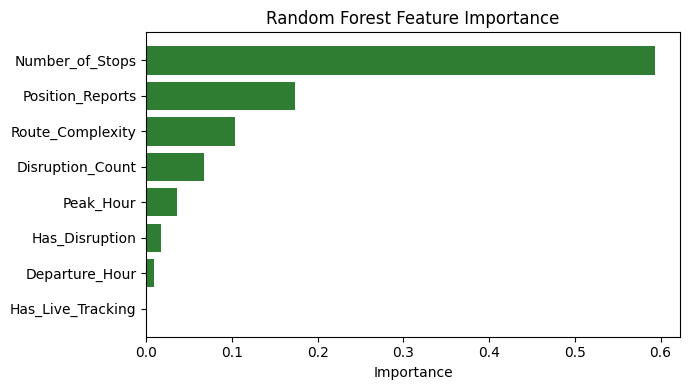

In [11]:
rf_fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.featureImportances.toArray()
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(7,4))
plt.barh(rf_fi_df["Feature"], rf_fi_df["Importance"], color="#2E7D32")
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.savefig(
    os.path.join(results_path, "feature_importance_rf.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

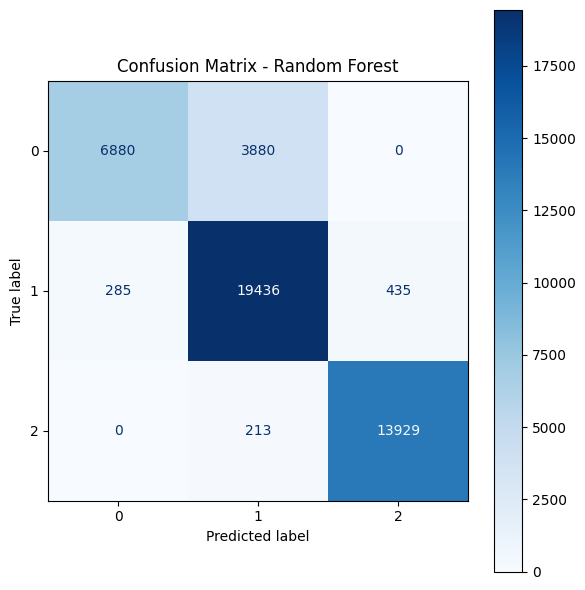

In [12]:
from pyspark.sql.functions import col
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Convert Spark predictions to Pandas
cm_df = rf_predictions.select(
    col("Service_Risk").cast("int"),
    col("prediction").cast("int")
).toPandas()

# Create confusion matrix
cm = confusion_matrix(
    cm_df["Service_Risk"],
    cm_df["prediction"]
)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix - Random Forest")
plt.tight_layout()

plt.savefig(
    os.path.join(results_path, "confusion_matrix_rf.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Model 3: Logistic Regression

In [13]:
from pyspark.ml.classification import LogisticRegression

lr = LogisticRegression(
    labelCol="Service_Risk",
    featuresCol="features",
    maxIter=30,
    regParam=0.1,
    elasticNetParam=0.2,
    family="multinomial"
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)

In [14]:
print("Logistic Regression Performance")

for metric in metrics:

    evaluator = MulticlassClassificationEvaluator(
        labelCol="Service_Risk",
        predictionCol="prediction",
        metricName=metric
    )

    score = evaluator.evaluate(lr_predictions)

    print(metric, ":", score)

Logistic Regression Performance
accuracy : 0.8074925651382663
weightedPrecision : 0.8126845854722832
weightedRecall : 0.8074925651382663
f1 : 0.8085480734499741


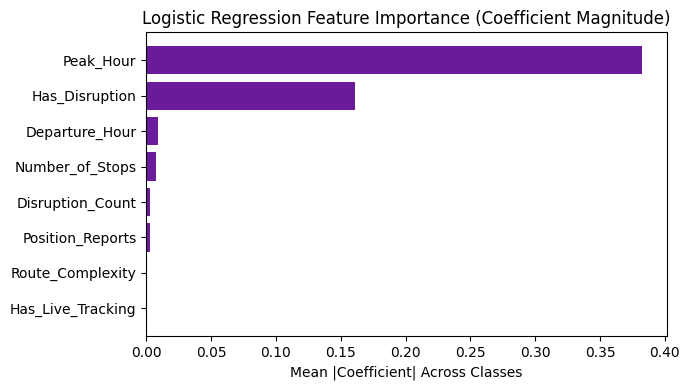

In [15]:
import numpy as np

coef_matrix = lr_model.coefficientMatrix.toArray()   # shape: (numClasses, numFeatures)
lr_importance = np.mean(np.abs(coef_matrix), axis=0)

lr_fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": lr_importance
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(7,4))
plt.barh(lr_fi_df["Feature"], lr_fi_df["Importance"], color="#6A1B9A")
plt.xlabel("Mean |Coefficient| Across Classes")
plt.title("Logistic Regression Feature Importance (Coefficient Magnitude)")
plt.tight_layout()
plt.savefig(
    os.path.join(results_path, "feature_importance_lr.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

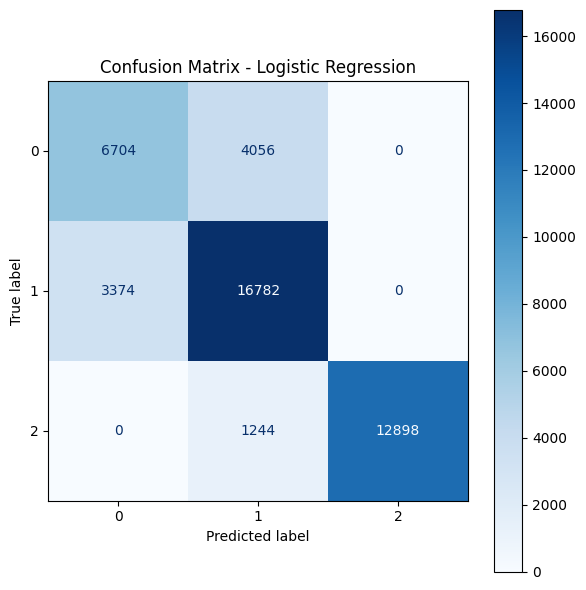

In [16]:
from pyspark.sql.functions import col
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert Spark DataFrame to Pandas
lr_cm_df = lr_predictions.select(
    col("Service_Risk").cast("int"),
    col("prediction").cast("int")
).toPandas()

# Create confusion matrix
cm = confusion_matrix(
    lr_cm_df["Service_Risk"],
    lr_cm_df["prediction"]
)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", ax=ax)

plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()

plt.savefig(
    os.path.join(results_path, "confusion_matrix_lr.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [17]:
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

In [18]:
evaluator_accuracy = MulticlassClassificationEvaluator(
    labelCol="Service_Risk",
    predictionCol="prediction",
    metricName="accuracy"
)


evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="Service_Risk",
    predictionCol="prediction",
    metricName="f1"
)

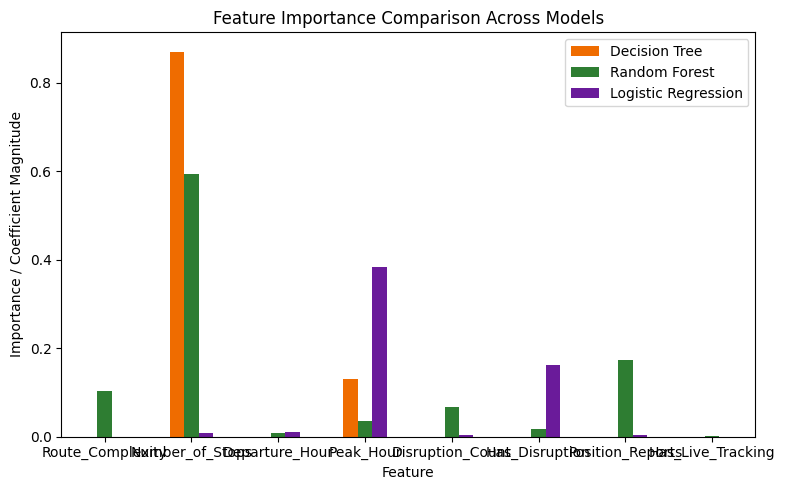

In [20]:
comparison_fi = pd.DataFrame({
    "Feature": feature_names,
    "Decision Tree": dt_model.featureImportances.toArray(),
    "Random Forest": rf_model.featureImportances.toArray(),
    "Logistic Regression": lr_importance
}).set_index("Feature")

comparison_fi.plot(kind="bar", figsize=(8,5), color=["#EF6C00", "#2E7D32", "#6A1B9A"])
plt.ylabel("Importance / Coefficient Magnitude")
plt.title("Feature Importance Comparison Across Models")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    os.path.join(results_path, "model_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [21]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression"
    ],
    
    "Accuracy": [
        0.893771,
        0.8918187,
        0.808230
    ],
    
    "Precision": [
        0.8940999,
        0.901998,
        0.813311
    ],
    
    "Recall": [
        0.8937719,
        0.891818,
        0.8082301
    ],
    
    "F1 Score": [
        0.891545,
        0.886563,
        0.809122
    ]
})


print(comparison)

                 Model  Accuracy  Precision    Recall  F1 Score
0        Decision Tree  0.893771   0.894100  0.893772  0.891545
1        Random Forest  0.891819   0.901998  0.891818  0.886563
2  Logistic Regression  0.808230   0.813311  0.808230  0.809122


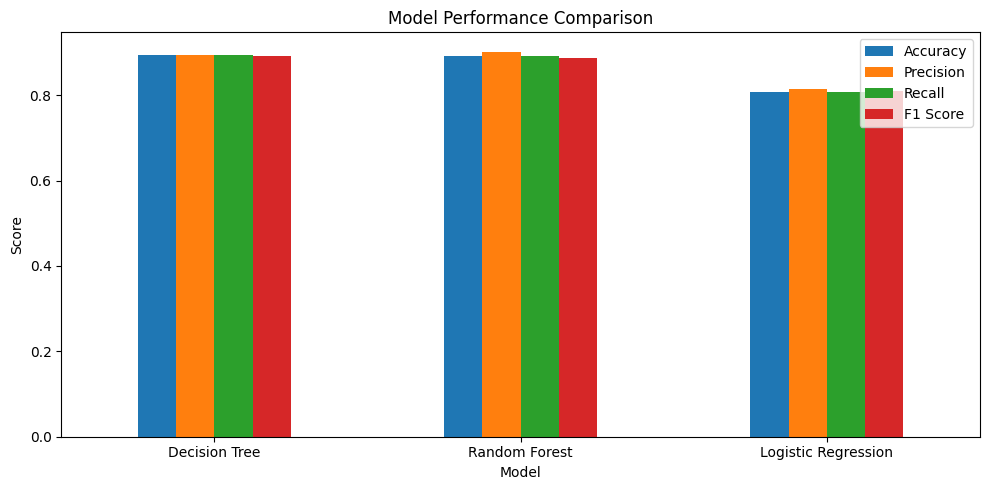

In [22]:
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    os.path.join(results_path, "precision_recall_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [24]:
confusion_matrix = (
    rf_predictions
    .groupBy("Service_Risk")
    .pivot("prediction")
    .count()
    .fillna(0)
    .orderBy("Service_Risk")
)

confusion_matrix.show()

+------------+----+-----+-----+
|Service_Risk| 0.0|  1.0|  2.0|
+------------+----+-----+-----+
|           0|6880| 3880|    0|
|           1| 285|19436|  435|
|           2|   0|  213|13929|
+------------+----+-----+-----+



In [25]:
rf_predictions.groupBy(
    "Service_Risk",
    "prediction"
).count().orderBy(
    "Service_Risk",
    "prediction"
).show(50)

+------------+----------+-----+
|Service_Risk|prediction|count|
+------------+----------+-----+
|           0|       0.0| 6880|
|           0|       1.0| 3880|
|           1|       0.0|  285|
|           1|       1.0|19436|
|           1|       2.0|  435|
|           2|       1.0|  213|
|           2|       2.0|13929|
+------------+----------+-----+



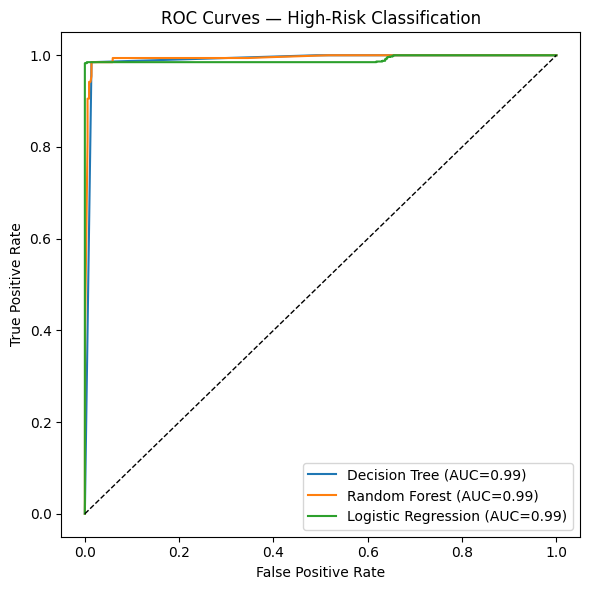

In [27]:
from sklearn.metrics import roc_curve, auc
from pyspark.sql.functions import col
import matplotlib.pyplot as plt

def get_roc_data(predictions_df, model_name):
    pdf = predictions_df.select(
        col("Service_Risk").cast("int"),
        "probability"
    ).toPandas()
    y_true = (pdf["Service_Risk"] == 2).astype(int)          # high-risk = 1
    y_score = pdf["probability"].apply(lambda v: v[2])       # prob of class 2
    fpr, tpr, _ = roc_curve(y_true, y_score)
    return fpr, tpr, auc(fpr, tpr), model_name

plt.figure(figsize=(6,6))
for preds, name in [(dt_predictions, "Decision Tree"),
                     (rf_predictions, "Random Forest"),
                     (lr_predictions, "Logistic Regression")]:
    fpr, tpr, roc_auc, label = get_roc_data(preds, name)
    plt.plot(fpr, tpr, label=f"{label} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'k--', linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — High-Risk Classification")
plt.legend()
plt.tight_layout()
plt.savefig(
    os.path.join(results_path, "roc_curves.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Feature Importance

In [28]:
feature_importance = rf_model.featureImportances

feature_names = [
    "Route_Complexity",
    "Number_of_Stops",
    "Departure_Hour",
    "Peak_Hour",
    "Disruption_Count",
    "Has_Disruption",
    "Position_Reports",
    "Has_Live_Tracking"
]


for feature, importance in zip(feature_names, feature_importance):
    print(feature, ":", importance)

Route_Complexity : 0.10347127786542616
Number_of_Stops : 0.5929689120908697
Departure_Hour : 0.008997681382528582
Peak_Hour : 0.035613700335291654
Disruption_Count : 0.06747969379231859
Has_Disruption : 0.017357472645010925
Position_Reports : 0.17391337136555637
Has_Live_Tracking : 0.00019789052299815525


In [30]:
results_path = os.path.join(project_path, "Data", "results")
model_path = os.path.join(project_path, "Data", "models")
prediction_path = os.path.join(processed_path, "predictions")

os.makedirs(results_path, exist_ok=True)
os.makedirs(model_path, exist_ok=True)

In [31]:
comparison.to_csv(
    os.path.join(results_path, "model_comparison.csv"),
    index=False
)

In [32]:
confusion_df = (
    rf_predictions
    .groupBy(
        "Service_Risk",
        "prediction"
    )
    .count()
    .orderBy(
        "Service_Risk",
        "prediction"
    )
    .toPandas()
)


confusion_df.to_csv(
    os.path.join(results_path, "confusion_matrix.csv"),
    index=False
)

print("Confusion matrix saved")


Confusion matrix saved


In [33]:
feature_importance_df = pd.DataFrame({
    "Feature": [
    "Route_Complexity",
    "Number_of_Stops",
    "Departure_Hour",
    "Peak_Hour",
    "Disruption_Count",
    "Has_Disruption",
    "Position_Reports",
    "Has_Live_Tracking"
],
    "Importance": rf_model.featureImportances.toArray()
})


feature_importance_df.to_csv(
    os.path.join(results_path, "feature_importance.csv"),
    index=False
)


print("Feature importance saved")

Feature importance saved


In [34]:
model_path = os.path.join(project_path, "Data", "models")
os.makedirs(model_path, exist_ok=True)

dt_model.write().overwrite().save(
    os.path.join(model_path, "decision_tree")
)

rf_model.write().overwrite().save(
    os.path.join(model_path, "random_forest")
)

lr_model.write().overwrite().save(
    os.path.join(model_path, "logistic_regression")
)

print("Models saved successfully.")

Models saved successfully.


In [35]:
prediction_path = os.path.join(processed_path, "predictions")
rf_predictions.write.mode("overwrite").parquet(
    prediction_path
)

print("Predictions saved.")

Predictions saved.
